Saving IMDb Movies India.csv to IMDb Movies India.csv
Dataset: 15,509 rows × 10 columns

            dtype  missing  miss_%
Name       object        0     0.0
Year      float64      528     3.4
Duration   object     8269    53.3
Genre      object     1877    12.1
Rating    float64     7590    48.9
Votes      object     7589    48.9
Director   object      525     3.4
Actor 1    object     1617    10.4
Actor 2    object     2384    15.4
Actor 3    object     3144    20.3

Rating stats:
count    7919.000
mean        5.842
std         1.382
min         1.100
25%         4.900
50%         6.000
75%         6.800
max        10.000
Name: Rating, dtype: float64

Rows after dropping unrated movies: 7,919

Feature matrix shape: (7919, 40)


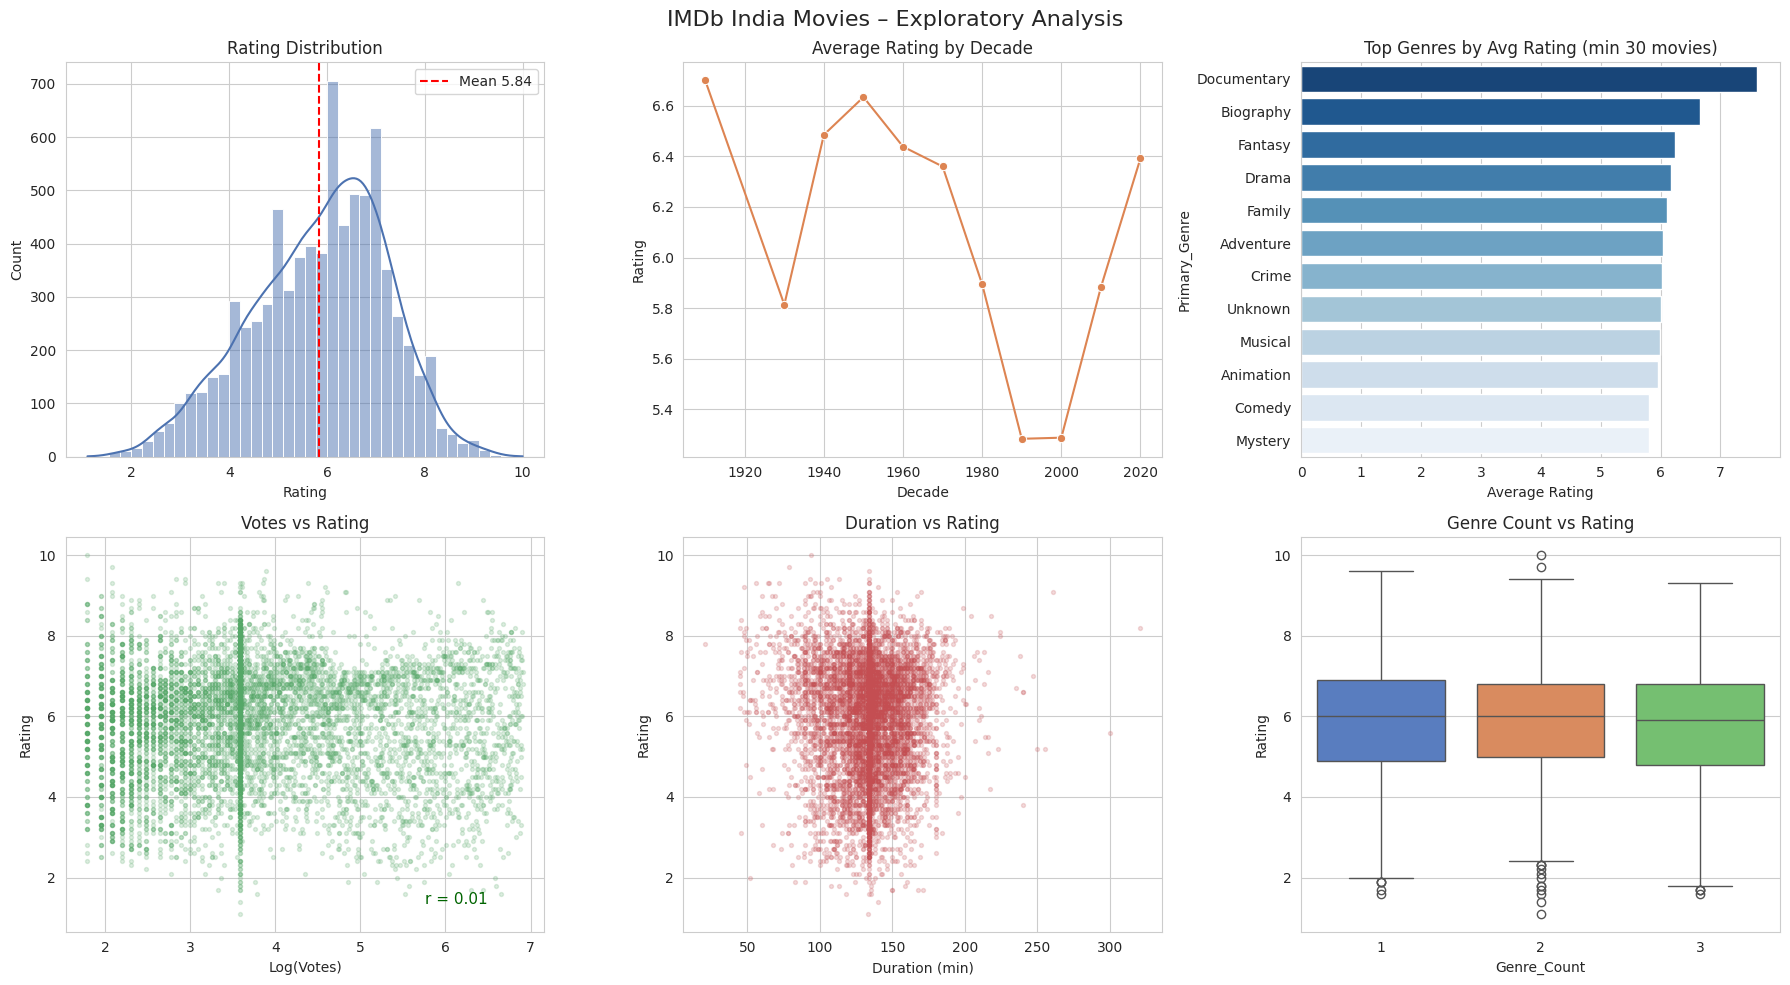

Train: 6335  |  Test: 1584

Model Comparison (5-Fold CV RMSE):
---------------------------------------------
  Linear Regression          RMSE = 0.8420  (±0.0140)
  Ridge                      RMSE = 0.8420  (±0.0140)
  Random Forest              RMSE = 0.8140  (±0.0219)
  Gradient Boosting          RMSE = 0.7996  (±0.0191)

Tuning Gradient Boosting …
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Best params : {'model__learning_rate': 0.03, 'model__max_depth': 4, 'model__n_estimators': 500, 'model__subsample': 0.8}
Best CV RMSE: 0.7924

  TEST SET RESULTS
  MAE  = 0.5267
  RMSE = 0.7804
  R²   = 0.6724


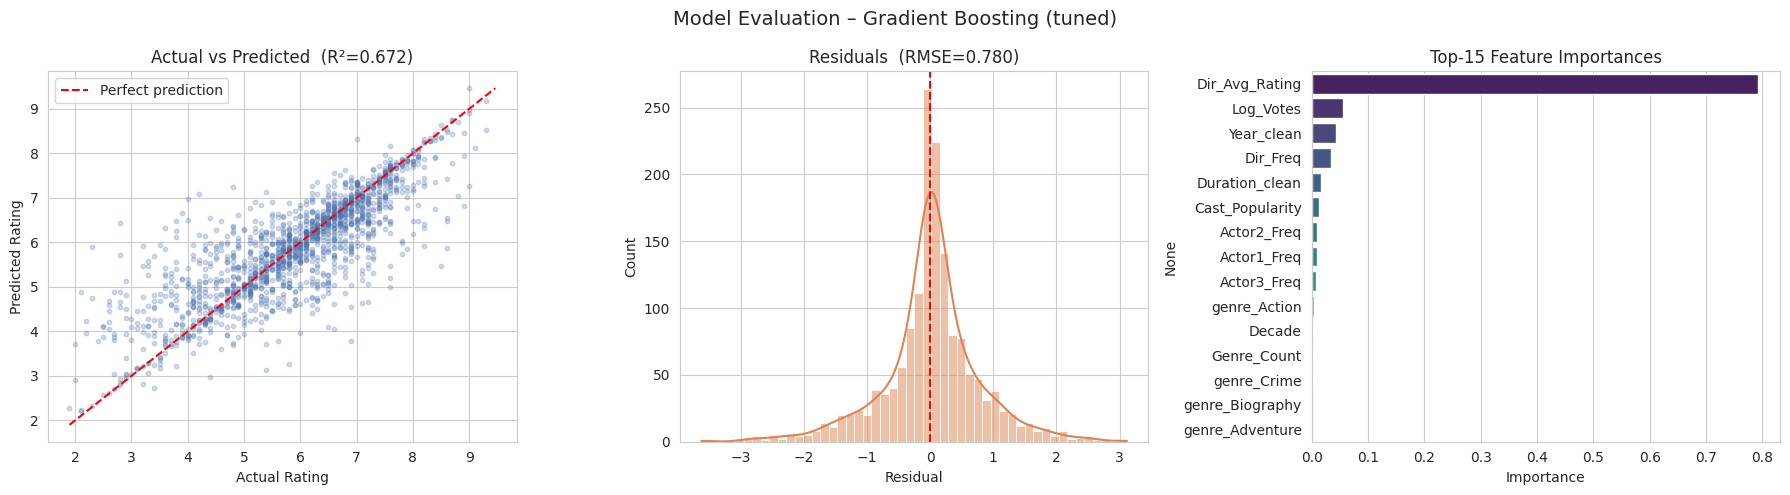


Sample Predictions:
    Actual   Predicted     Error
  --------------------------------
      5.80        6.18     0.383
      7.20        7.32     0.117
      5.00        5.03     0.034
      6.60        6.65     0.055
      6.30        6.53     0.229
      6.20        6.49     0.288
      8.60        7.43     1.168
      6.30        4.70     1.599
      5.00        5.42     0.417
      7.70        7.17     0.527

Model saved as  movie_rating_model.pkl


In [ ]:

# CODSOFT DATA SCIENCE INTERNSHIP
# TASK 2: MOVIE RATING PREDICTION WITH PYTHON
# AUTHOR: SALIK KHAN



#  Install / imports
import re
import warnings
import pickle
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection  import (train_test_split, cross_val_score,
                                       KFold, GridSearchCV)
from sklearn.preprocessing    import StandardScaler
from sklearn.pipeline         import Pipeline
from sklearn.linear_model     import LinearRegression, Ridge
from sklearn.ensemble         import (RandomForestRegressor,
                                       GradientBoostingRegressor)
from sklearn.metrics          import (mean_absolute_error,
                                       mean_squared_error, r2_score)
from sklearn.impute            import SimpleImputer

warnings.filterwarnings("ignore")
np.random.seed(42)

# Upload your CSV in Colab
from google.colab import files
uploaded = files.upload()   # pick IMDb_Movies_India.csv
DATA_PATH = list(uploaded.keys())[0]


# 1.  LOAD & AUDIT

df_raw = pd.read_csv(DATA_PATH, encoding="latin-1")
print(f"Dataset: {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns\n")

audit = pd.DataFrame({
    "dtype"  : df_raw.dtypes,
    "missing": df_raw.isnull().sum(),
    "miss_%" : (df_raw.isnull().mean() * 100).round(1)
})
print(audit)
print(f"\nRating stats:\n{df_raw['Rating'].describe().round(3)}")


# 2.  CLEANING

def parse_duration(val):
    if pd.isna(val): return np.nan
    nums = re.findall(r"\d+", str(val))
    return float(nums[0]) if nums else np.nan

def clean_year(val):
    if pd.isna(val): return np.nan
    return abs(float(val))

df = df_raw.copy()
df = df[df["Rating"].notna()].reset_index(drop=True)
print(f"\nRows after dropping unrated movies: {len(df):,}")

df["Year"]     = df["Year"].apply(clean_year)
df["Duration"] = df["Duration"].apply(parse_duration)

str_cols = ["Name","Genre","Director","Actor 1","Actor 2","Actor 3"]
for c in str_cols:
    df[c] = df[c].astype(str).str.strip().replace("nan", np.nan)

df["Votes"]     = pd.to_numeric(df["Votes"], errors="coerce")
df["Votes"]     = df["Votes"].fillna(df["Votes"].median())
df["Log_Votes"] = np.log1p(df["Votes"])


# 3.  FEATURE ENGINEERING

def frequency_encode(series):
    freq = series.value_counts(normalize=True)
    return series.map(freq).fillna(0.0)

# Year & Decade
df["Year_clean"]     = df["Year"].fillna(df["Year"].median())
df["Decade"]         = (df["Year_clean"] // 10 * 10).astype(int)

# Duration
df["Duration_clean"] = df["Duration"].fillna(df["Duration"].median())

# Genre
df["Genre_clean"]    = df["Genre"].fillna("Unknown")
df["Primary_Genre"]  = df["Genre_clean"].str.split(",").str[0].str.strip()
df["Genre_Count"]    = df["Genre_clean"].apply(
    lambda x: len(x.split(",")) if x != "Unknown" else 0)

# Genre dummies (top 12)
top_genres = df["Primary_Genre"].value_counts().head(12).index.tolist()
for g in top_genres:
    df[f"genre_{g.replace(' ','_')}"] = (df["Primary_Genre"] == g).astype(int)

# Cast & Director encoding
df["Director_clean"] = df["Director"].fillna("Unknown")
df["Actor1_clean"]   = df["Actor 1"].fillna("Unknown")
df["Actor2_clean"]   = df["Actor 2"].fillna("Unknown")
df["Actor3_clean"]   = df["Actor 3"].fillna("Unknown")

df["Dir_Freq"]       = frequency_encode(df["Director_clean"])
df["Actor1_Freq"]    = frequency_encode(df["Actor1_clean"])
df["Actor2_Freq"]    = frequency_encode(df["Actor2_clean"])
df["Actor3_Freq"]    = frequency_encode(df["Actor3_clean"])

df["Cast_Popularity"]  = (df["Actor1_Freq"]*0.5 +
                           df["Actor2_Freq"]*0.3 +
                           df["Actor3_Freq"]*0.2)

dir_avg                = df.groupby("Director_clean")["Rating"].mean()
df["Dir_Avg_Rating"]   = df["Director_clean"].map(dir_avg).fillna(df["Rating"].mean())
df["Is_Modern"]        = (df["Year_clean"] >= df["Year_clean"].median()).astype(int)

print(f"\nFeature matrix shape: {df.shape}")


# 4.  EXPLORATORY DATA ANALYSIS

sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("IMDb India Movies – Exploratory Analysis", fontsize=16)

# Rating distribution
ax = axes[0,0]
sns.histplot(df["Rating"], bins=40, kde=True, color="#4C72B0", ax=ax)
ax.axvline(df["Rating"].mean(), color="red", linestyle="--",
           label=f"Mean {df['Rating'].mean():.2f}")
ax.set_title("Rating Distribution"); ax.legend()

# Avg rating by decade
ax = axes[0,1]
decade_avg = df.groupby("Decade")["Rating"].mean().reset_index()
sns.lineplot(data=decade_avg, x="Decade", y="Rating", marker="o",
             color="#DD8452", ax=ax)
ax.set_title("Average Rating by Decade")

# Top genres by avg rating
ax = axes[0,2]
genre_avg = (df.groupby("Primary_Genre")["Rating"]
               .agg(["mean","count"])
               .query("count >= 30")
               .sort_values("mean", ascending=False)
               .head(12))
sns.barplot(x=genre_avg["mean"], y=genre_avg.index, palette="Blues_r", ax=ax)
ax.set_title("Top Genres by Avg Rating (min 30 movies)")
ax.set_xlabel("Average Rating")

# Log Votes vs Rating
ax = axes[1,0]
ax.scatter(df["Log_Votes"], df["Rating"], alpha=0.2, s=8, color="#55A868")
corr = df[["Log_Votes","Rating"]].corr().iloc[0,1]
ax.set_xlabel("Log(Votes)"); ax.set_ylabel("Rating")
ax.set_title("Votes vs Rating")
ax.annotate(f"r = {corr:.2f}", xy=(0.75,0.07), xycoords="axes fraction",
            fontsize=11, color="darkgreen")

# Duration vs Rating
ax = axes[1,1]
ax.scatter(df["Duration_clean"], df["Rating"], alpha=0.2, s=8, color="#C44E52")
ax.set_xlabel("Duration (min)"); ax.set_ylabel("Rating")
ax.set_title("Duration vs Rating")

# Genre count vs Rating
ax = axes[1,2]
df_box = df[df["Genre_Count"].between(1,5)]
sns.boxplot(x="Genre_Count", y="Rating", data=df_box, palette="muted", ax=ax)
ax.set_title("Genre Count vs Rating")

plt.tight_layout()
plt.show()


# 5.  FEATURE MATRIX + TRAIN/TEST SPLIT

BASE_FEATURES = [
    "Year_clean","Decade","Duration_clean","Log_Votes","Genre_Count",
    "Dir_Freq","Actor1_Freq","Actor2_Freq","Actor3_Freq",
    "Cast_Popularity","Dir_Avg_Rating","Is_Modern",
]
genre_dummies = [c for c in df.columns if c.startswith("genre_")]
ALL_FEATURES  = BASE_FEATURES + genre_dummies

X = df[ALL_FEATURES].values
y = df["Rating"].values

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Train: {X_tr.shape[0]}  |  Test: {X_te.shape[0]}")


# 6.  MODEL COMPARISON  (5-fold CV)


cv = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "Linear Regression": Pipeline([
        ("imp",   SimpleImputer(strategy="median")),
        ("scl",   StandardScaler()),
        ("model", LinearRegression()),
    ]),
    "Ridge": Pipeline([
        ("imp",   SimpleImputer(strategy="median")),
        ("scl",   StandardScaler()),
        ("model", Ridge(alpha=1.0)),
    ]),
    "Random Forest": Pipeline([
        ("imp",   SimpleImputer(strategy="median")),
        ("model", RandomForestRegressor(n_estimators=300, max_depth=12,
                                        min_samples_leaf=4, random_state=42,
                                        n_jobs=-1)),
    ]),
    "Gradient Boosting": Pipeline([
        ("imp",   SimpleImputer(strategy="median")),
        ("model", GradientBoostingRegressor(n_estimators=400, learning_rate=0.05,
                                             max_depth=5, subsample=0.8,
                                             random_state=42)),
    ]),
}

print("\nModel Comparison (5-Fold CV RMSE):")
print("-"*45)
cv_results = {}
for name, pipe in models.items():
    scores = cross_val_score(pipe, X_tr, y_tr, cv=cv,
                             scoring="neg_root_mean_squared_error", n_jobs=-1)
    rmse = -scores.mean()
    cv_results[name] = rmse
    print(f"  {name:<25}  RMSE = {rmse:.4f}  (±{scores.std():.4f})")


# 7.  HYPER-PARAMETER TUNING (Gradient Boosting)

print("\nTuning Gradient Boosting …")

param_grid = {
    "model__n_estimators"  : [300, 500],
    "model__learning_rate" : [0.03, 0.05],
    "model__max_depth"     : [4, 5],
    "model__subsample"     : [0.8, 1.0],
}

base_pipe = Pipeline([
    ("imp",   SimpleImputer(strategy="median")),
    ("model", GradientBoostingRegressor(random_state=42)),
])

gs = GridSearchCV(base_pipe, param_grid, cv=3,
                  scoring="neg_root_mean_squared_error",
                  n_jobs=-1, verbose=1)
gs.fit(X_tr, y_tr)

print(f"\nBest params : {gs.best_params_}")
print(f"Best CV RMSE: {-gs.best_score_:.4f}")
best_model = gs.best_estimator_


# 8.  FINAL EVALUATION

y_pred = best_model.predict(X_te)

mae  = mean_absolute_error(y_te, y_pred)
rmse = mean_squared_error(y_te, y_pred) ** 0.5
r2   = r2_score(y_te, y_pred)

print(f"\n{'='*40}")
print(f"  TEST SET RESULTS")
print(f"  MAE  = {mae:.4f}")
print(f"  RMSE = {rmse:.4f}")
print(f"  R²   = {r2:.4f}")
print(f"{'='*40}")

residuals = y_te - y_pred

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Model Evaluation – Gradient Boosting (tuned)", fontsize=14)

# Actual vs Predicted
ax = axes[0]
ax.scatter(y_te, y_pred, alpha=0.25, s=10, color="#4C72B0")
lims = [min(y_te.min(), y_pred.min()), max(y_te.max(), y_pred.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
ax.set_xlabel("Actual Rating"); ax.set_ylabel("Predicted Rating")
ax.set_title(f"Actual vs Predicted  (R²={r2:.3f})"); ax.legend()

# Residuals
ax = axes[1]
sns.histplot(residuals, bins=50, kde=True, color="#DD8452", ax=ax)
ax.axvline(0, color="red", linestyle="--")
ax.set_xlabel("Residual"); ax.set_title(f"Residuals  (RMSE={rmse:.3f})")

# Feature importances
ax = axes[2]
importances = best_model.named_steps["model"].feature_importances_
fi = (pd.Series(importances, index=ALL_FEATURES)
        .sort_values(ascending=False)
        .head(15))
sns.barplot(x=fi.values, y=fi.index, palette="viridis", ax=ax)
ax.set_title("Top-15 Feature Importances"); ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()


# 9.  SAMPLE PREDICTIONS

print("\nSample Predictions:")
print(f"  {'Actual':>8}  {'Predicted':>10}  {'Error':>8}")
print("  " + "-"*32)
idx = np.random.choice(len(y_te), size=10, replace=False)
for i in idx:
    print(f"  {y_te[i]:>8.2f}  {y_pred[i]:>10.2f}  {abs(y_te[i]-y_pred[i]):>8.3f}")


# 10. SAVE MODEL

with open("movie_rating_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
print("\nModel saved as  movie_rating_model.pkl")